In [1]:
import pandas as pd

In [2]:
dataset=pd.read_csv("telecom_churn.csv")

In [3]:
dataset.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='calls_made', ylabel='Count'>

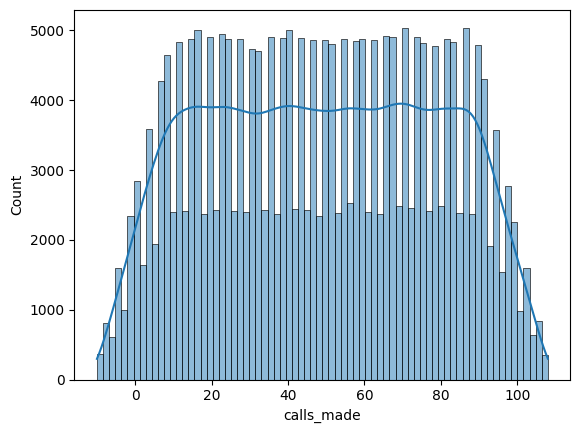

In [9]:
sns.histplot(dataset["calls_made"], kde=True)

In [10]:
#Probablity Density function = PDF
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    #kernel density function (kde) to get the curve
    sns.histplot(dataset, kde=True, color='green')
    #vline - vertical line
    plt.axvline(startrange,color='Red')
    plt.axvline(endrange,color='Red')
    #generate a sample
    sample = dataset
    #calculate parameters
    sample_mean = dataset.mean()  # Finds average of dataset
    sample_std = dataset.std()    # Calculate Standard Deviation
    #Prints values rounded to 3 decimals
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    #define the normal distribution, #norm from scipy.stats import norm
    dist=norm(sample_mean, sample_std)
    #sample probablity for a range of outcomes / Generates numbers between start and end
    values=[value for value in range(startrange,endrange)]
    #pdf is a function
    probabilities = [dist.pdf(value) for value in values]
    #summation / Adds all PDF values
    prob=sum(probabilities)
    print("The area between range ({},{}):{}".format(startrange,endrange,sum(probabilities)))
    #Returns total probability
    return prob

Mean=49.011, Standard Deviation=29.454
The area between range (40,60):0.2657571131139731


np.float64(0.2657571131139731)

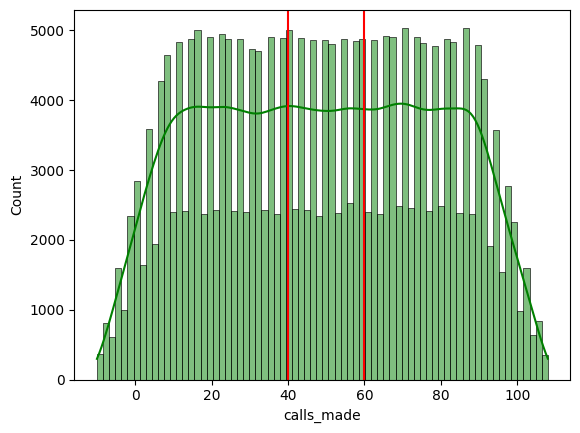

In [11]:
get_pdf_probability(dataset['calls_made'],40,60)

In [12]:
#empirical cumulative density function ECDF
from statsmodels.distributions.empirical_distribution import ECDF
ecdf=ECDF(dataset['calls_made'])
ecdf(70)

np.float64(0.7148793075839756)

In [13]:
#standard normal distribution
def stdNDgraph(dataset):
    import seaborn as sns
    #import matplotlib.pyplot as plt
    mean=dataset.mean()
    std=dataset.std()
    values=[i for i in dataset]
    z_score=[((j - mean)/std)for j in values]
    sns.histplot(z_score,kde=True)
    return sum(z_score)/len(z_score)


np.float64(-4.619770049949862e-16)

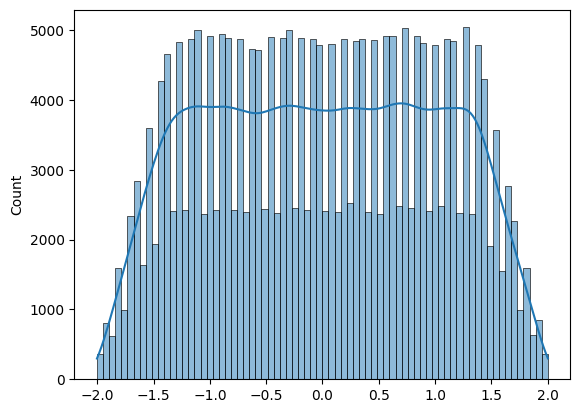

In [14]:
stdNDgraph(dataset['calls_made'])